## Module 4: Cancer

## Team Members:
Jake Carnell and Tahseen Azad

## Project Title:
Predicting Age-Associated Patterns of Angiogenesis Gene Expression in Glioblastoma Multiforme Using Machine Learning and Dimensionality Reduction


## Project Goal:
The goal of this project is to analyze angiogenesis-related gene expression patterns in glioblastoma multiforme (GBM) using TCGA-derived expression data. Dimensionality reduction techniques (PCA and UMAP) and clustering methods are used to explore structure within angiogenesis gene expression profiles. In addition, a supervised machine learning model is trained to classify GBM patients into younger and older age groups based on angiogenesis gene expression features. Together, these approaches aim to uncover potential relationships between angiogenesis activity and patient age, providing insight into GBM tumor biology.

## Disease Background:

* Cancer hallmark focus: Angiogenesis is defined as the growth of new blood cells from existing blood cells. In cancers, the new growth of vascular networks provide the high demand of nutrients required by highly metabolic tumor cells. 

* Overview of hallmark: In GBM, angiogenesis is triggered by hypoxia which means low oxygen delivery to throughout the blood tissues. Low oxygen levels throughout the tissues triggers hypoxia-induced factors such as HIF-1 or HIF-2 which then go on to activate pro-angiogenic factors such as VEGF. The newly created vascular network is abnormal and disrupts the effectiveness of the blood brain barrier and leads to vascular edema.

* Genes associated with hallmark to be studied (you can point to a CSV with the list of genes you will study, or point to a citation with a gene signature of interest): A predefined set of angiogenesis-related genes was obtained frm the Menyhart JPA Cancer Hallmarks Core gene set. This curated gene list represents genes associated with the "Sustained Angiogenesis" hallmark of cancer and was used to subset the gene expression dataset for analysis.

This study focuses exclusively on Glioblastoma multiforme (GBM), the most common and aggressive primary malignant brain tumor in adults. GBM's hallmark reliance on angiogenesis -- driven by its hypoxic microenvironment and rapid vascularization -- makes it a particularly instructive model for studying the role of tumor vasculature in progression and clinical outcomes. By concentrating on a single cancer type, the analysis aims to provide a more detailed and disease-specific understanding of these mechanisms.

* Prevalence & incidence ~ GBM is the most common malignant primary brain tumor in adults, accounting for approximately 45-50% of all malignant brain tumors. It has an incidence of about 3-5 cases per 100,000 people per year, with a median survival of 12-15 months and a 5-year survival rate of less than 10%.

* Risk factors (genetic, lifestyle) & Societal determinants ~ Most cases of GBM are sporadic, though genetic alterations such as TP53 mutations, EGFR amplification, and PTEN loss are common. The only well-known established environmental risk factor is ionizing radiation exposure, while socioeconomic factors and access to specialized care can influence patient outcomes. 

* Standard of care treatments (& reimbursement) ~ The standard treatment for GBM includes surgical resection followed by radiotherapy and chemotherapy with Temozolomide. Additional therapies, such as Bevacizumab, may be used, though access to these treatments can vary.

* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology) ~ GBM is characterized by rapid growth, extensive invasion into surrounding brain tissue, and high vascularization driven by angiogenesis. Hypoxia within the tumor microenvironment activates HIF-1α (Hypoxia-inducible factor 1-alpha), which promotes VEGF-mediated blood vessel formation, contributing to tumor progression, heterogeneity, and treatment resistance.


## Data-Set: 

This data-set is from The Cancer Genome Atlas RNA-seq dataset which was re-processed by Rahman et al. It consists of 24 different cancer types, including GBM. The data set also includes 1802 tumor samples across all 24 types of cancer. The data set expresses gene expression derived from RNA-sequencing using transcripts per million on a logarithmic scale. Additionally, the dataset includes information rgearding patient profiles 



## Data Analysis: 

### Methods
The machine learning techniques used in this analysis incude Principal Component Analysis (PCA), Uniform Manifold Approximation and Projection (UMAP), and KMeans clustering. PCA is a linear dimensionality reduction method that identifies directions (principal components) that capture the greatest variance in gene expression data. UMAP is a nonlinear dimensionality reduction technique that preserves local and global structure in the data, allowing for better visualization of complex relationships. KMeans clustering is used to group genes with similar expression patterns across GBM samples. The algorithm groups genes into clusters by minimizing within-cluster sum of squared distances.

### Analysis

#### 1. Importing Libraries
The necessary Python libraries for data manipulation, visualization, and machine learning were first imported.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import umap

#### 2. Loading the Dataset
The gene expression dataset and associated metadata were loaded using pandas.

In [51]:
data = pd.read_csv(
    'c:/Users/vkb5cq/Desktop/Spring 2026/BME 2315/Module-4-Cancer/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0
)

metadata_df = pd.read_csv(
    'c:/Users/vkb5cq/Desktop/Spring 2026/BME 2315/Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv',
    index_col=0
)

#### 3. Inspecting the Data
Initial inspection was performed to understand the structure and contents of the dataset.

In [52]:
print(data.head())
print(data.shape)
print(data.info())

print(metadata_df.head())
print(metadata_df.info())

        TCGA-E9-A1NI-01A-11R-A14D-07  TCGA-E2-A1LK-01A-21R-A14D-07  \
A1BG                        3.397369                      3.466089   
A1CF                        0.008857                      0.039562   
A2M                         7.575125                      6.643613   
A2ML1                       0.397610                      7.625124   
A4GALT                      5.277425                      5.244677   

        TCGA-BH-A0B2-01A-11R-A10J-07  TCGA-E2-A107-01A-11R-A10J-07  \
A1BG                        3.789771                      3.967578   
A1CF                        0.065051                      0.000000   
A2M                         9.024479                      7.573842   
A2ML1                       0.428689                      0.465410   
A4GALT                      4.072650                      4.208381   

        TCGA-LL-A5YN-01A-11R-A28M-07  TCGA-BH-A0DQ-01A-11R-A084-07  \
A1BG                        4.733007                      3.011343   
A1CF              

#### 4. Loading Angiogenesis Gene List
A prefefined list of angiogenesis-related genes was loaded and extracted.

In [53]:
df = pd.read_csv(
    r"c:/Users/vkb5cq/Desktop/Spring 2026/BME 2315/Module-4-Cancer/Menyhart_JPA_CancerHallmarks_core.txt",
    sep='\t'
)

angiogenesis_row = df[df.iloc[:, 0] == "SUSTAINED ANGIOGENESIS"]
genes = angiogenesis_row.iloc[0, 1:].dropna()

desired_gene_list = genes.tolist()

#### 5. Subsetting GBM samples
The dataset was first subsetted to include only GBM samples using metadata labels.

In [54]:
cancer_type = 'GBM'
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index

GBM_data = data[cancer_samples]
GBM_metadata = metadata_df.loc[cancer_samples]

#### 6. Filtering Angiogenesis Genes
The above list of angiogenesis-related genes was used to filter the dataset.

In [55]:
gene_list = [gene for gene in desired_gene_list if gene in GBM_data.index]
GBM_gene_data = GBM_data.loc[gene_list]

Only genes present in both the dataset and angiogenesis list were retained.

#### 7. Data Cleaning & Scaling
The data was cleaned by removing duplicates, handling missing values, and standardizing gene expression values.

In [56]:
GBM_data = GBM_data.apply(pd.to_numeric, errors='coerce')
GBM_data = GBM_data.fillna(GBM_data.mean(axis=1), axis=0)

X = GBM_gene_data.T
X_scaled = StandardScaler().fit_transform(X)


#### 8. Creating Age Labels

In [57]:
age = pd.to_numeric(
    GBM_metadata.loc[X.index, "age_at_diagnosis"],
    errors="coerce"
)

age_cutoff = 60
age_group = (age > age_cutoff).astype(int)

# Align indices
age_group = age_group.loc[GBM_gene_data.columns]

print("\nAge group counts (0=younger, 1=older):")
print(age_group.value_counts())


Age group counts (0=younger, 1=older):
age_at_diagnosis
0    49
1    31
Name: count, dtype: int64


#### 8. Exploratory Analysis
Variability of gene expression was examined to identify genes contributing most to differences across samples.

In [58]:
GBM_gene_data.var(axis=1).sort_values(ascending=False).head(10)

EGFR      5.389307
PDGFRA    4.921669
IL8       4.622747
CXCL13    3.765673
CCL2      3.145472
CXCL10    2.658209
VEGFA     2.402845
THBS1     2.338787
IL6       2.318849
TWIST1    1.818240
dtype: float64

#### 9. PCA (dimensionality reduction)
PCA was applied to reduce dimensionality and identify patterns of co-expression among angiogenesis genes.

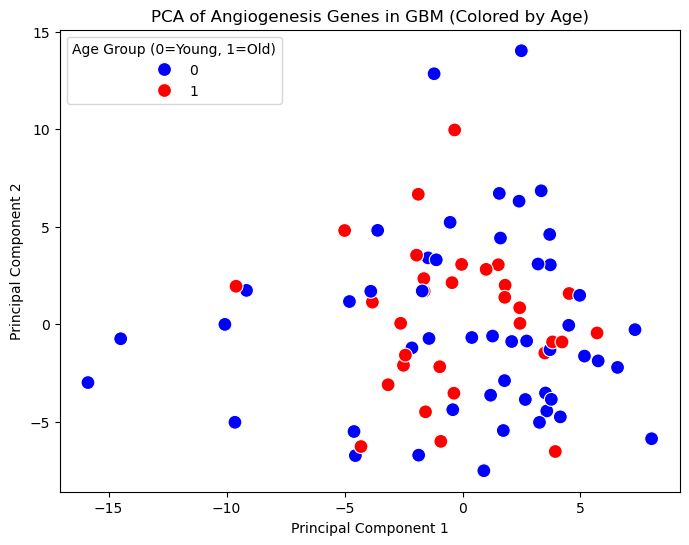

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=age_group,
    palette=["blue", "red"],
    s=100
)

plt.title("PCA of Angiogenesis Genes in GBM (Colored by Age)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Age Group (0=Younger, 1=Older)")

plt.show()


Each point in the PCA plot represents a gene, and proximity indicates similarity in expression patterns.

#### 10. UMAP (nonlinear dimensionality reduction)
UMAP was used to capture nonlinear relationships in gene expression data.

c:\Users\vkb5cq\AppData\Local\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


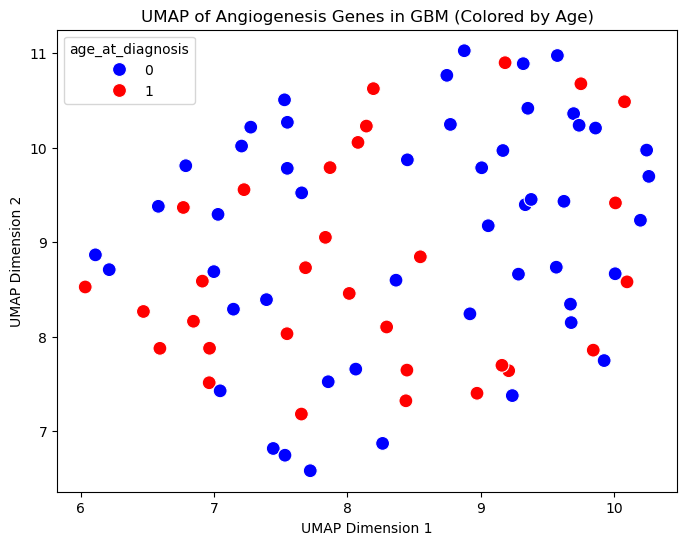

In [60]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=age_group,
    palette=["blue", "red"],
    s=100
)

plt.title("UMAP of Angiogenesis Genes in GBM (Colored by Age)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.show()


UMAP can reveal clustering patterns not visible in PCA.

#### 11. Clustering (KMeans)
KMeans clustering was applied to group genes with similar expression patterns.

c:\Users\vkb5cq\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


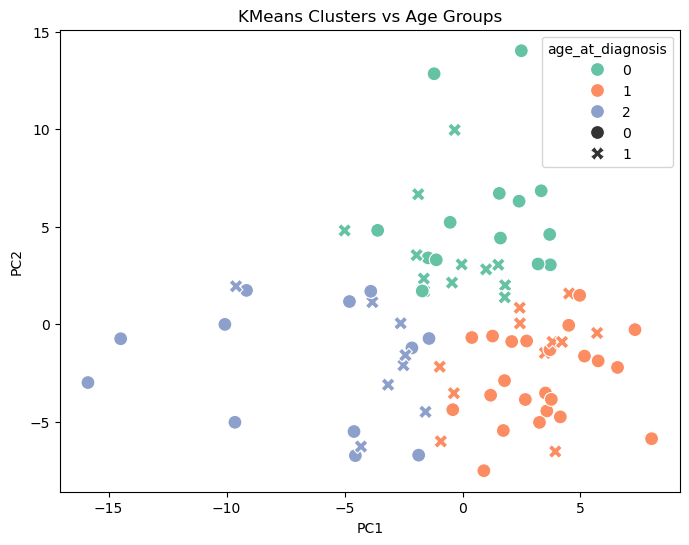

In [61]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=clusters,
    style=age_group,
    palette="Set2",
    s=100
)

plt.title("KMeans Clusters vs Age Groups")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

Genes with the same cluster are likely co-expressed and may belong to similar biological pathways.

#### 12. Prepare Data for Machine Learning
We’ll use logistic regression to predict a categorical clinical outcome from gene expression data. Our inputs are expression levels of angiogenesis-related genes, and the output is a clinical label like tumor subtype or a survival category.

Logistic regression is a good fit here because it’s built for classification problems like this one and tends to work well with high-dimensional gene expression data. It’s also fairly stable, especially when regularization is used to handle lots of genes at once. Another big advantage is that it’s easy to interpret—we can see which genes are most strongly linked to the outcome, which is really useful for biological insight.

In [62]:
X = GBM_gene_data.T  # patients as rows

# Clean and convert age
age = GBM_metadata.loc[X.index, "age_at_diagnosis"]
age = pd.to_numeric(age, errors='coerce')

# Drop missing ages
valid_idx = age.dropna().index
X = X.loc[valid_idx]
age = age.loc[valid_idx]

# Binary classification: older vs younger
age_cutoff = 60
y = (age > age_cutoff).astype(int)

print("\nML dataset shape:", X.shape)
print("\nClass balance:\n", y.value_counts())


ML dataset shape: (70, 111)

Class balance:
 age_at_diagnosis
0    39
1    31
Name: count, dtype: int64


This matrix is highlighting that there are 39 "young" patients and 31 "older" patients in our sample.

#### 13. Splitting the Data

GBM not in validation dataset, need to split data. REVISE

In [63]:
train_idx, temp_idx = train_test_split(
    X.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=y.loc[temp_idx]
)

X_train = X.loc[train_idx]
X_val = X.loc[val_idx]

y_train = y.loc[train_idx]
y_val = y.loc[val_idx]

print("\nTrain size:", X_train.shape)
print("Validation size:", X_val.shape)


Train size: (56, 111)
Validation size: (7, 111)


#### 14. Feature Selection

In [64]:
# Select top 30 most variable genes from training set ONLY
gene_variance = X_train.var(axis=0)
top_genes = gene_variance.sort_values(ascending=False).head(30).index

print("\nUsing top genes:", list(top_genes))

X_train = X_train[top_genes]
X_val = X_val[top_genes]


Using top genes: ['PDGFRA', 'EGFR', 'IL8', 'CCL2', 'CXCL10', 'CXCL13', 'VEGFA', 'THBS1', 'CX3CR1', 'TWIST1', 'CXCL9', 'IL6', 'MET', 'IL1B', 'PDGFA', 'CAV1', 'CXCL12', 'SDC4', 'PRKCG', 'CSF3', 'MMP1', 'TGFB2', 'ERBB2', 'CXCR4', 'PRKCB', 'ANGPT2', 'SDC2', 'PLAUR', 'CCL11', 'SPHK1']


#### 15. Scale the Data

In [65]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

#### 16. Logistic Regression

In [66]:
model = LogisticRegression(
    penalty='l2',              # FIX: stable regularization
    C=1.0,                     # FIX: not too aggressive
    solver='liblinear',
    class_weight='balanced',   # FIX: handles imbalance
    max_iter=1000,
    random_state=42
)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


#### 17. Evaluate the Model

In [67]:
y_pred = model.predict(X_val_scaled)

print("\nACCURACY:", accuracy_score(y_val, y_pred))

print("\nCONFUSION MATRIX:")
print(confusion_matrix(y_val, y_pred))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_val, y_pred))


ACCURACY: 0.5714285714285714

CONFUSION MATRIX:
[[2 2]
 [1 2]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       0.50      0.67      0.57         3

    accuracy                           0.57         7
   macro avg       0.58      0.58      0.57         7
weighted avg       0.60      0.57      0.57         7



#### 18. Gene Importance

In [68]:
coefficients = pd.DataFrame({
    "Gene": top_genes,
    "Coefficient": model.coef_[0]
})

coefficients["Interpretation"] = coefficients["Coefficient"].apply(
    lambda x: "OLDER" if x > 0 else "YOUNGER"
)

print("\nTop genes (OLDER):")
print(coefficients.sort_values(by="Coefficient", ascending=False).head(10))

print("\nTop genes (YOUNGER):")
print(coefficients.sort_values(by="Coefficient").head(10))


Top genes (OLDER):
      Gene  Coefficient Interpretation
6    VEGFA     0.898174          OLDER
16  CXCL12     0.812624          OLDER
2      IL8     0.642896          OLDER
27   PLAUR     0.613348          OLDER
28   CCL11     0.423965          OLDER
4   CXCL10     0.418029          OLDER
14   PDGFA     0.375881          OLDER
1     EGFR     0.369177          OLDER
8   CX3CR1     0.355876          OLDER
24   PRKCB     0.353639          OLDER

Top genes (YOUNGER):
      Gene  Coefficient Interpretation
10   CXCL9    -0.623259        YOUNGER
15    CAV1    -0.613673        YOUNGER
7    THBS1    -0.487589        YOUNGER
11     IL6    -0.444141        YOUNGER
3     CCL2    -0.281987        YOUNGER
19    CSF3    -0.222024        YOUNGER
9   TWIST1    -0.213186        YOUNGER
12     MET    -0.193069        YOUNGER
25  ANGPT2    -0.110267        YOUNGER
21   TGFB2    -0.031810        YOUNGER


#### 19. Creating Confusion Matrix 

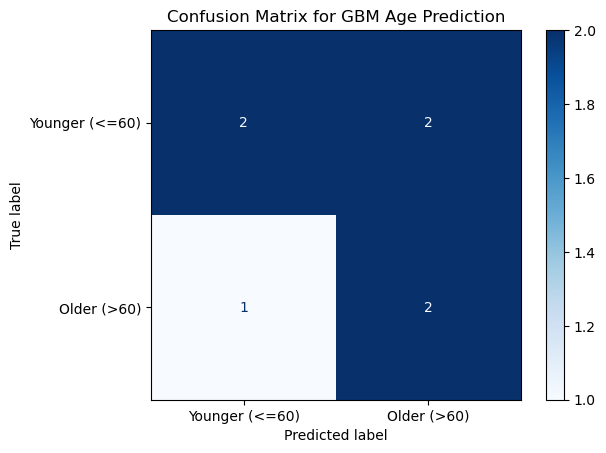

In [69]:
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Younger (<=60)", "Older (>60)"]
)

disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix for GBM Age Prediction")
plt.show()

#### 20. Evaluating Error

In [70]:
accuracy = accuracy_score(y_val, y_pred)
error_rate = 1 - accuracy

print(f"\nModel Accuracy: {accuracy:.4f}")
print(f"Model Error Rate: {error_rate:.4f}")

# Training performance
y_train_pred = model.predict(X_train_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

gap = train_accuracy - accuracy
print(f"Overfitting Gap: {gap:.4f}")


Model Accuracy: 0.5714
Model Error Rate: 0.4286

Training Accuracy: 0.8750
Validation Accuracy: 0.5714
Overfitting Gap: 0.3036


#### 21. Improving the Model

In [71]:
model = LogisticRegression(
    penalty='l2',              # FIX: stable regularization
    C=0.1,                     # FIX: not too aggressive
    solver='liblinear',
    class_weight='balanced',   # FIX: handles imbalance
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


#### 21. Repeat Steps 17-20

In [72]:
y_pred = model.predict(X_val_scaled)

print("\nACCURACY:", accuracy_score(y_val, y_pred))

print("\nCONFUSION MATRIX:")
print(confusion_matrix(y_val, y_pred))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_val, y_pred))


ACCURACY: 0.7142857142857143

CONFUSION MATRIX:
[[2 2]
 [0 3]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         4
           1       0.60      1.00      0.75         3

    accuracy                           0.71         7
   macro avg       0.80      0.75      0.71         7
weighted avg       0.83      0.71      0.70         7



In [73]:
coefficients = pd.DataFrame({
    "Gene": top_genes,
    "Coefficient": model.coef_[0]
})

coefficients["Interpretation"] = coefficients["Coefficient"].apply(
    lambda x: "OLDER" if x > 0 else "YOUNGER"
)

print("\nTop genes (OLDER):")
print(coefficients.sort_values(by="Coefficient", ascending=False).head(10))

print("\nTop genes (YOUNGER):")
print(coefficients.sort_values(by="Coefficient").head(10))


Top genes (OLDER):
      Gene  Coefficient Interpretation
16  CXCL12     0.309811          OLDER
6    VEGFA     0.255520          OLDER
13    IL1B     0.243011          OLDER
14   PDGFA     0.215000          OLDER
27   PLAUR     0.211119          OLDER
1     EGFR     0.174434          OLDER
8   CX3CR1     0.173614          OLDER
2      IL8     0.158593          OLDER
22   ERBB2     0.143588          OLDER
20    MMP1     0.113224          OLDER

Top genes (YOUNGER):
      Gene  Coefficient Interpretation
9   TWIST1    -0.148779        YOUNGER
15    CAV1    -0.142091        YOUNGER
19    CSF3    -0.108880        YOUNGER
11     IL6    -0.107332        YOUNGER
10   CXCL9    -0.096025        YOUNGER
7    THBS1    -0.086201        YOUNGER
12     MET    -0.085956        YOUNGER
3     CCL2    -0.067552        YOUNGER
21   TGFB2    -0.031212        YOUNGER
26    SDC2    -0.025628        YOUNGER


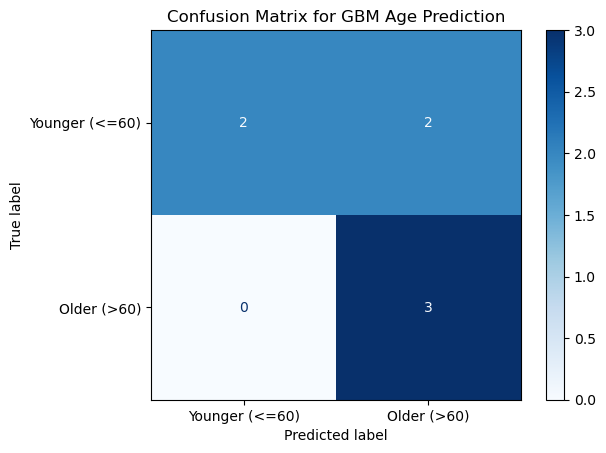

In [74]:
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Younger (<=60)", "Older (>60)"]
)

disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix for GBM Age Prediction")
plt.show()

In [75]:
accuracy = accuracy_score(y_val, y_pred)
error_rate = 1 - accuracy

print(f"\nModel Accuracy: {accuracy:.4f}")
print(f"Model Error Rate: {error_rate:.4f}")

# Training performance
y_train_pred = model.predict(X_train_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

gap = train_accuracy - accuracy
print(f"Overfitting Gap: {gap:.4f}")


Model Accuracy: 0.7143
Model Error Rate: 0.2857

Training Accuracy: 0.8393
Validation Accuracy: 0.7143
Overfitting Gap: 0.1250


## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## References

Ostrom, Q. T., et al. (2023). CBTRUS statistical report: Primary brain and other central nervous system tumors diagnosed in the United States. Neuro-Oncology.

Stupp, R., et al. (2005). Radiotherapy plus concomitant and adjuvant temozolomide for glioblastoma. New England Journal of Medicine, 352(10), 987–996.

Wen, P. Y., & Kesari, S. (2008). Malignant gliomas in adults. New England Journal of Medicine, 359(5), 492–507.

Cancer Genome Atlas Research Network. (2008). Comprehensive genomic characterization of glioblastoma. Nature, 455(7216), 1061–1068.

Friedman, H. S., et al. (2009). Bevacizumab alone and in combination for recurrent glioblastoma. Journal of Clinical Oncology, 27(28), 4733–4740.

Jain, R. K., et al. (2007). Antiangiogenic therapy in cancer. Nature Reviews Clinical Oncology.

Semenza, G. L. (2003). Targeting HIF-1 for cancer therapy. Nature Reviews Cancer, 3(10), 721–732.

AI tools (ChatGPT) were used in the development of this assignment to assist with structuring content, summarizing scientific sources, and improving clarity of writing. The final work reflects our own understanding, and all information was reviewed and verified using primary literature sources.


## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*